In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn

     ---------------------------------------- 9.9/9.9 MB 35.1 MB/s eta 0:00:00
     --------------------------------------- 12.6/12.6 MB 50.4 MB/s eta 0:00:00
     ---------------------------------------- 8.1/8.1 MB 40.0 MB/s eta 0:00:00
     ------------------------------------- 294.9/294.9 kB 17.8 MB/s eta 0:00:00
     ---------------------------------------- 8.1/8.1 MB 51.7 MB/s eta 0:00:00
     ---------------------------------------- 349.0/349.0 kB ? eta 0:00:00
     ------------------------------------- 225.2/225.2 kB 13.4 MB/s eta 0:00:00
     ---------------------------------------- 2.3/2.3 MB 29.9 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB 4.0 MB/s eta 0:00:00
     ---------------------------------------- 7.1/7.1 MB 45.0 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 7.0 MB/s eta 0:00:00
     --------------------------------------- 36.6/36.6 MB 43.7 MB/s eta 0:00:00
     ------------------------------------- 309.1/3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style = 'whitegrid')

En este caso, el archivo se carga directamente desde mi cuenta de azure, por lo que debo implementar la siguiente funcion:

In [3]:
%pip install azure-storage-blob

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 15.6 MB/s eta 0:00:00


from azure.storage.blob import BlobServiceClient
import io

def read_dataset_from_azure(
    connection_string: str,
    container_name: str,
    blob_name: str
) -> pd.DataFrame:
    """
    Lee un dataset desde Azure Blob Storage y lo retorna como DataFrame.

    Parámetros:
    -----------
    connection_string : str
        Connection string de tu Azure Storage Account.
        (encuéntrala en Azure Portal → Storage Account → Access keys)
    container_name : str
        Nombre del contenedor (blob container).
    blob_name : str
        Ruta/nombre del archivo dentro del contenedor.
        Ej: "datos/ventas_2024.csv" o simplemente "ventas_2024.parquet"

    Retorna:
    --------
    pd.DataFrame con los datos del archivo.
    """
    # Conectar al servicio
    service_client = BlobServiceClient.from_connection_string(connection_string)
    blob_client = service_client.get_blob_client(
        container=container_name,
        blob=blob_name
    )

    # Descargar el contenido en memoria
    print(f"Descargando '{blob_name}' desde el contenedor '{container_name}'...")
    stream = blob_client.download_blob()
    data = stream.readall()
    buffer = io.BytesIO(data)

    # Detectar formato por extensión
    ext = blob_name.lower().split(".")[-1]

    if ext == "csv":
        df = pd.read_csv(buffer)
    elif ext == "parquet":
        df = pd.read_parquet(buffer)
    elif ext == "json":
        df = pd.read_json(buffer)
    elif ext in ("xlsx", "xls"):
        df = pd.read_excel(buffer)
    else:
        raise ValueError(f"Formato '.{ext}' no soportado. Agrega tu lógica de lectura.")

    print(f" Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
    return df

In [6]:
df = pd.read_csv('AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


#### Necesitamos hallar información sobre las columnas, cantidad de datos y enfocarnos en el input (isFraud)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

En ese caso, las columnas que el sistema deecta como fraudulentas, son 16. Por otra parte, las que verdaderamente son fraudulentas constan de +8200 valores

In [11]:
# Corroboramos que no haya ningun valor NaN

print(f"{df.isnull().sum()}")
print("")
print(f"{df.shape}")

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

(6362620, 11)


El dataset se encuentra limpio

In [12]:
# Hallamos el porcentaje de datos fraudulentos dividiendo estos por el total
res = df["isFraud"].value_counts()[1] / df.shape[0]
print(f"{round((res * 100),2)}%")

0.13%


Text(0, 0.5, 'Contador')

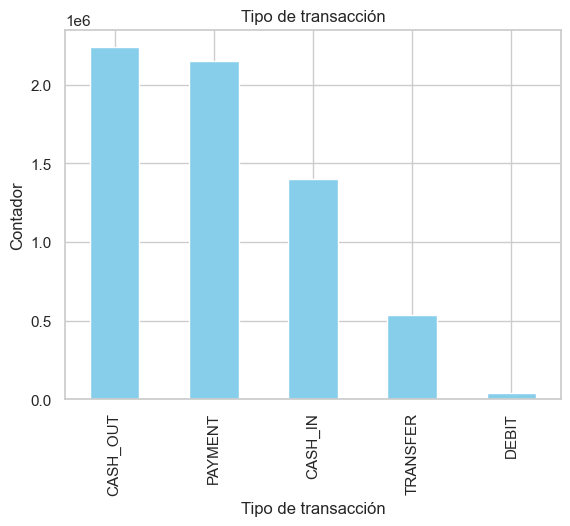

In [13]:
# Visualizamos que tantos tipos de transacciones hay
df['type'].value_counts().plot(kind = 'bar', title = 'Tipo de transacción', color = 'skyblue',)
plt.xlabel('Tipo de transacción')
plt.ylabel('Contador')

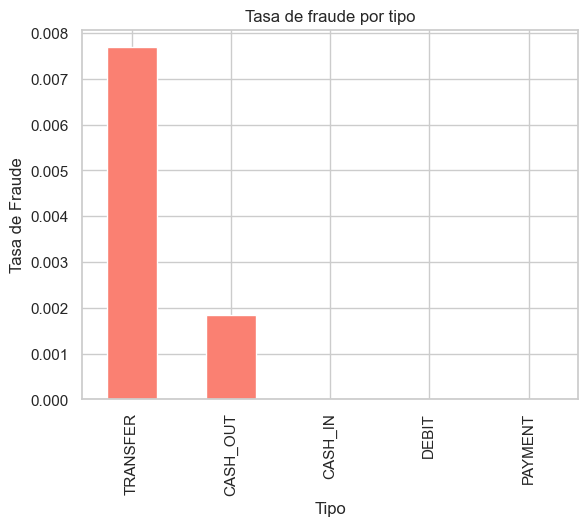

In [14]:
fraude_por_tipo = df.groupby('type')['isFraud'].mean().sort_values(ascending = False)
fraude_por_tipo.plot(kind = 'bar', title = 'Tasa de fraude por tipo', color = 'salmon')
plt.ylabel('Tasa de Fraude')
plt.xlabel('Tipo')
plt.show()

Tenemos que los mayores fraudes son por transferencia y por retiro de dinero. En ingreso de dinero, débito y pago los fraudes son de cero, lo que tiene mucho sentido.

In [15]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

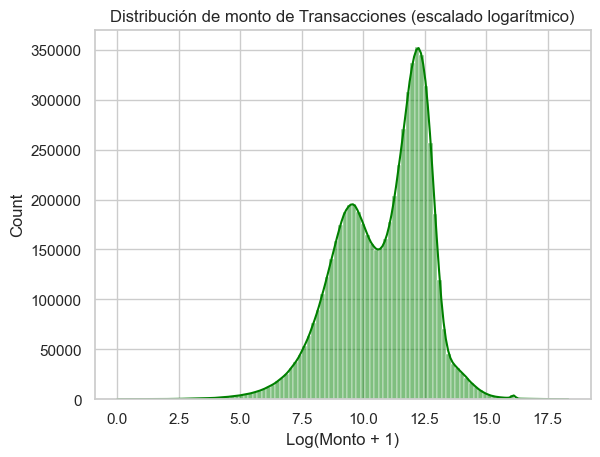

In [16]:
sns.histplot(np.log1p(df['amount']), bins = 100, kde = True, color = 'green')
plt.title('Distribución de monto de Transacciones (escalado logarítmico)')
plt.xlabel('Log(Monto + 1)')
plt.show()

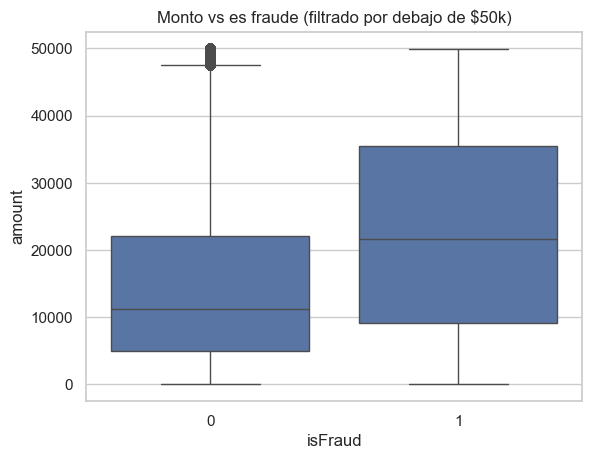

In [17]:
sns.boxplot(data = df[df['amount'] < 50000], x = 'isFraud', y = 'amount')
plt.title('Monto vs es fraude (filtrado por debajo de $50k)')
plt.show()

In [18]:
df['balance_diff_original'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [19]:
(df['balance_diff_dest'] < 0).sum()

np.int64(1238864)

In [20]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_original,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


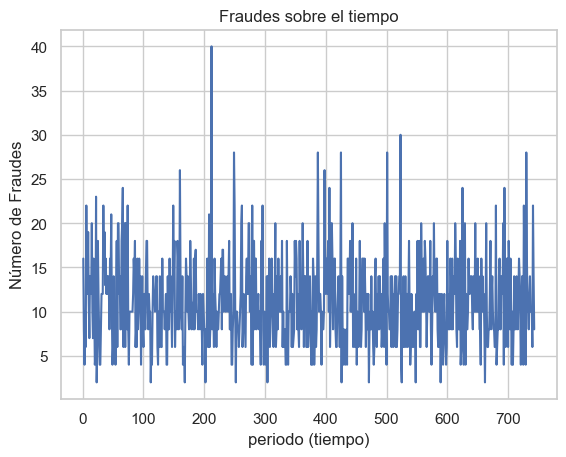

In [21]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label = 'Fradus per step')
plt.xlabel('periodo (tiempo)')
plt.ylabel('Número de Fraudes')
plt.title('Fraudes sobre el tiempo')
plt.grid(True)
plt.show()

In [22]:
df.drop(columns = 'step', inplace = True) #Droppeamos step por al nueva feature creada

In [23]:
df.head() # Ya no está step

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_original,balance_diff_dest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [24]:
#Info de los que mas envían dinero
top_senders = df['nameOrig'].value_counts().head(10)
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [25]:
# Info de los que más reciben dinero
top_recievers = df['nameDest'].value_counts().head(10)
top_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [26]:
# Info de usuarios tachados de fraude
fraud_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

Como vimos antteriormente, la mayor cantidad de fraudes se concentra en las transferencias y los retiros. Vamos a analizarlos

In [27]:
fraud_types = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

In [28]:
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

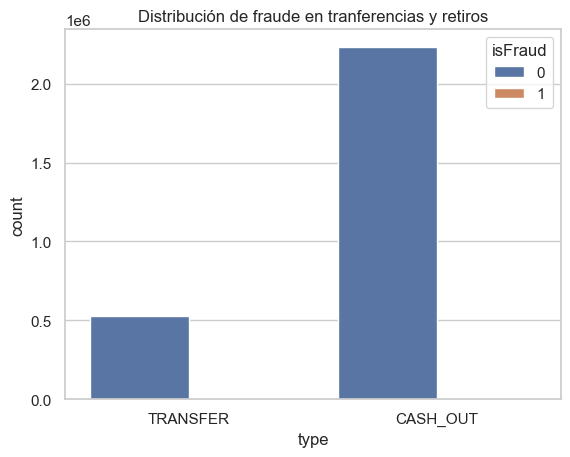

In [29]:
#Let´'s plot the results
sns.countplot(data = fraud_types, x = 'type', hue = 'isFraud')
plt.title('Distribución de fraude en tranferencias y retiros')
plt.show()

In [30]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balance_diff_original', 'balance_diff_dest'],
      dtype='str')

In [31]:
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


Podemos visualizarlo mejor con un mapa de calor

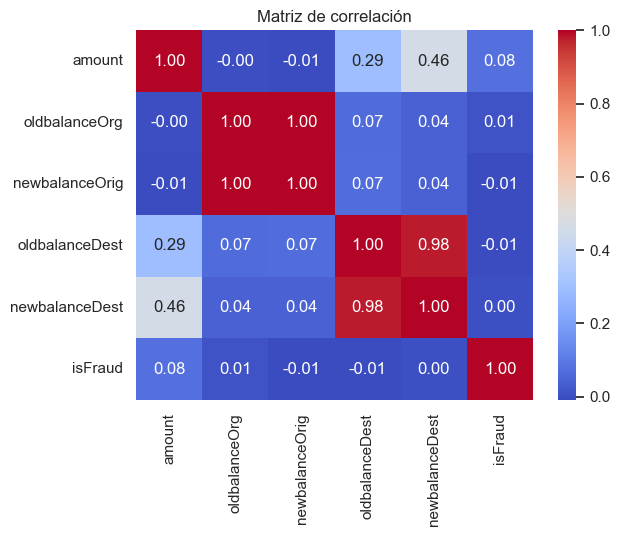

In [32]:
sns.heatmap(data = corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Matriz de correlación')
plt.show()

In [33]:
# Vamos a ver cuales clientes tienen balance de 0 luego de tranferir
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) & 
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_original,balance_diff_dest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


Hemos terminado con el análisis exploratiorio (EDA), seguiremos con la ingeniería de características

In [34]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split #Para separar la data en entrnamiento y testeto
from sklearn.preprocessing import StandardScaler, OneHotEncoder #Escalar la data y para tranformaciones
from sklearn.linear_model import LogisticRegression # El modelo de clasificación
from sklearn.metrics import classification_report, confusion_matrix # Metricas de evaluación
from sklearn.pipeline import Pipeline #Entrenar el modelo y hacer las tranformaciones del modelo
from sklearn.compose import ColumnTransformer # Tranformación

In [36]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_original,balance_diff_dest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [37]:
# Vamos a eliminar columnas

df_model = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1)
#Se droppean por tener valores únicos y el flaggeo del sistema no es eficiente. pueden desajutsar el modelo

In [38]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff_original,balance_diff_dest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [39]:
categorical = ['type']
numerical = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

In [40]:
y = df_model['isFraud']
X = df_model.drop('isFraud', axis = 1)

In [41]:
# Tenemos una cantidad bastante amlía de datos, por lo que asignaremos 30% al entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)

In [42]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop = 'first'), categorical)
    ],
    remainder = 'drop'
)

In [43]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight = 'balanced', max_iter = 1000)) 
])

Usamos el balanced porque el 99% de muestra data no es fraude. pero no queremos que el modelo solo envíe inputs de 'no es fraude'. 

In [44]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [45]:
y_pred = pipeline.predict(X_test)

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.95      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [47]:
confusion_matrix(y_test, y_pred)

array([[1802991,  103331],
       [    125,    2339]])

Bien, en general tenemos un modelo que es bueno captando el fraude pero no tiene una precisión muy sobresaliente. Sin embargo, se pueden implementar métodos como SMOTE o ADASYN para balanceo y también usar otros modelos, sin emabrgo, en este caso no se usará, aunque no se descarta un archivo futuro para encontrar un modelo más eficiente con el fin de desplegarlo

In [55]:
print(f'La precisión del modelo (LogisticRegression) es: {round(pipeline.score(X_test, y_test) * 100, 4)}%')

La precisión del modelo (LogisticRegression) es: 94.58%


Vamos a exportar la pipeline

In [56]:
import joblib

joblib.dump(pipeline, 'fraud_detection_pipeline.pkl')

['fraud_detection_pipeline.pkl']

In [57]:
%pip install streamlit

     ---------------------------------------- 9.1/9.1 MB 6.8 MB/s eta 0:00:00
     -------------------------------------- 795.4/795.4 kB 3.8 MB/s eta 0:00:00
     -------------------------------------- 108.4/108.4 kB 3.2 MB/s eta 0:00:00
     -------------------------------------- 208.6/208.6 kB 3.2 MB/s eta 0:00:00
     ---------------------------------------- 6.9/6.9 MB 2.6 MB/s eta 0:00:00
     -------------------------------------- 437.9/437.9 kB 1.2 MB/s eta 0:00:00
     ---------------------------------------- 27.5/27.5 MB 3.0 MB/s eta 0:00:00
     ---------------------------------------- 64.9/64.9 kB 3.6 MB/s eta 0:00:00
     ---------------------------------------- 79.1/79.1 kB 4.6 MB/s eta 0:00:00
     -------------------------------------- 134.9/134.9 kB 4.0 MB/s eta 0:00:00
     ---------------------------------------- 90.6/90.6 kB 2.5 MB/s eta 0:00:00
     -------------------------------------- 447.0/447.0 kB 4.6 MB/s eta 0:00:00
     ---------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
